
<font size="5">**HW 2: Power Plant Data Set**</font>


**A. Combined Cycle Power Plant Data**

In [6]:
import pandas as pd
import numpy as np

xls = pd.ExcelFile('/Folds5x2_pp.xlsx')
all_sheets = {}
for sheet_name in xls.sheet_names:
    all_sheets[sheet_name] = pd.read_excel(xls, sheet_name=sheet_name)



**B. Exploring Data**

In [7]:
# i.
combined_df = pd.concat(all_sheets.values(), ignore_index=True)

print(f"Total data (rows, columns): {combined_df.shape}")
display(combined_df.head())

print('Columns represent the variables used to predict hourly electrical power output')
print('Ambient Temperature (AT)')
print('Exhaust Steam Pressure (V)')
print('Atmospheric Pressure (AP)')
print('Relative Humidity (RH)')
print('Energy Output (PE)')

print('AT, V, AP, RH are used to predict PE')

Total data (rows, columns): (47840, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Columns represent the variables used to predict hourly electrical power output
Ambient Temperature (AT)
Exhaust Steam Pressure (V)
Atmospheric Pressure (AP)
Relative Humidity (RH)
Energy Output (PE)
AT, V, AP, RH are used to predict PE


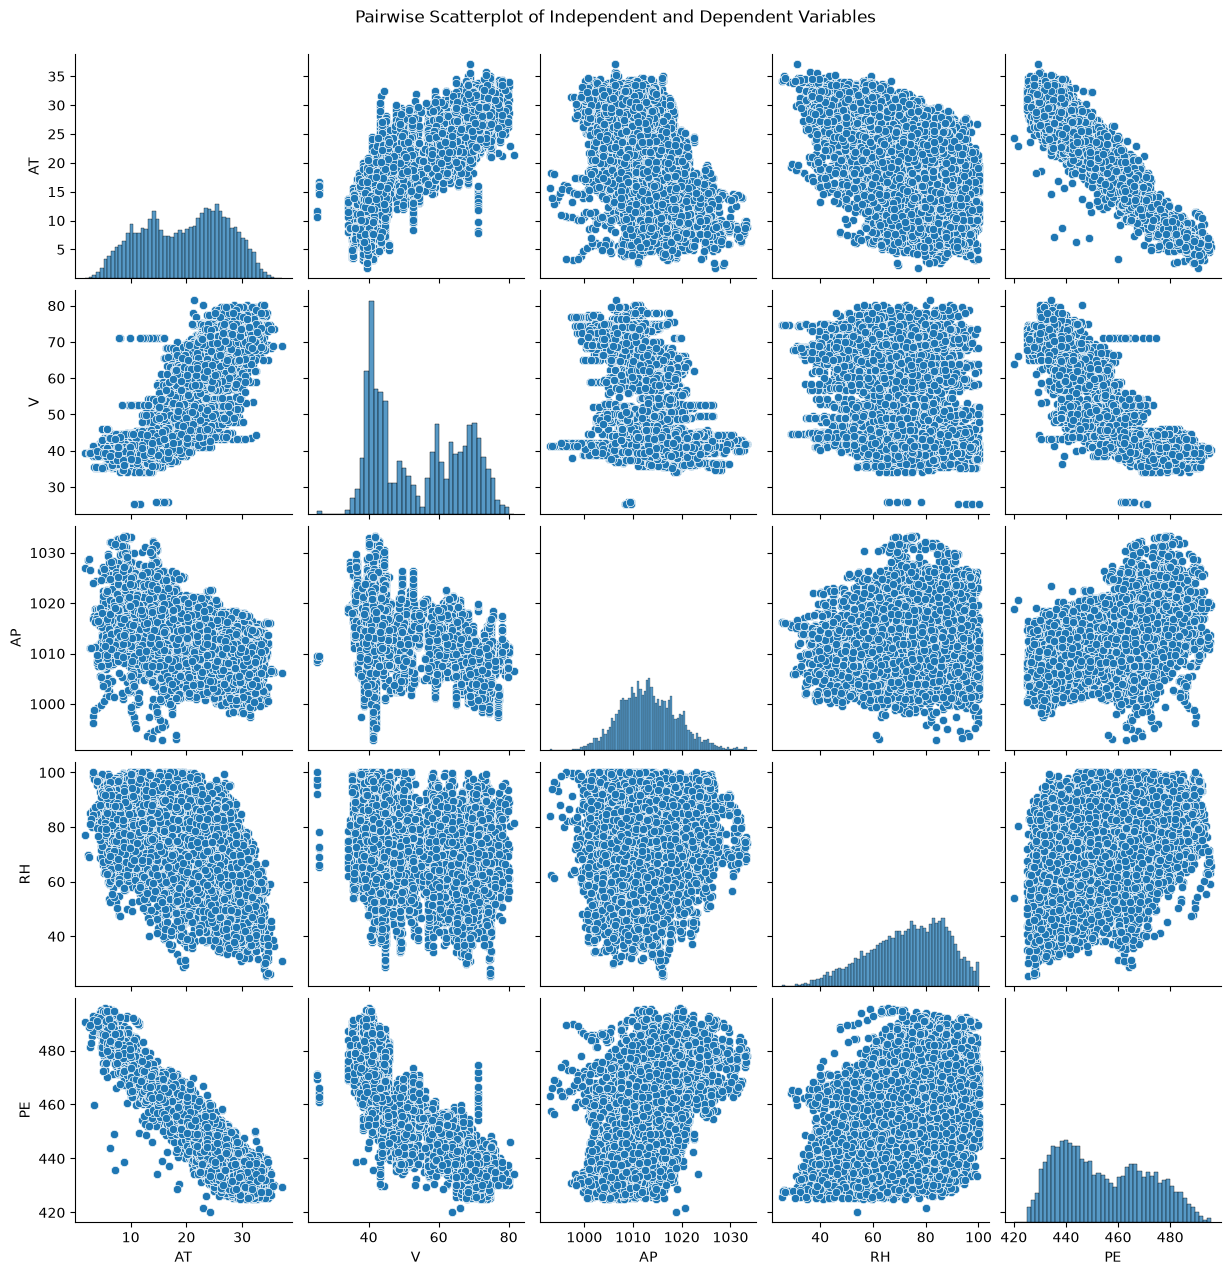

Diagonal scatterplots are the distribution of each individual variable
There seems to be a linear correlation between the ambient temperature and energy output
as well as the plots describing exhaust vacuum pressure and energy output.
Plots of relative humidity and energy ouput seem to have no linear correlation, as well 
as the plot showing ambient pressure and energy output


In [ ]:
# ii. Pairwise Scatterplots

import seaborn as sns
import matplotlib.pyplot as plt

columns_for_plot = ['AT', 'V', 'AP', 'RH', 'PE']
df_for_plot = combined_df[columns_for_plot]

sns.pairplot(df_for_plot)
plt.suptitle('Pairwise Scatterplot of Independent and Dependent Variables', y=1.02)
plt.show()

print("""Diagonal scatterplots are the distribution of each individual variable
There seems to be a linear correlation between the ambient temperature and energy output
as well as the plots describing exhaust vacuum pressure and energy output.
Plots of relative humidity and energy ouput seem to have no linear correlation, as well
as the plot showing ambient pressure and energy output""")



In [ ]:
# iii. Mean, median, range, 1st & 3rd quartile

summary_stats = combined_df[['AT', 'V', 'AP', 'RH', 'PE']].describe().transpose()

# range (max - min)
summary_stats['range'] = combined_df[['AT', 'V', 'AP', 'RH', 'PE']].max() - combined_df[['AT', 'V', 'AP', 'RH', 'PE']].min()

# Interquartile Range (IQR)
summary_stats['iqr'] = summary_stats['75%'] - summary_stats['25%']

# Rename columns for clarity
summary_stats = summary_stats.rename(columns={'50%': 'median', '25%': '1st_quartile', '75%': '3rd_quartile'})

# Select and reorder desired columns
final_summary = summary_stats[['mean', 'median', 'range', '1st_quartile', '3rd_quartile', 'iqr']]

display(final_summary)



,mean,median,range,1st_quartile,3rd_quartile,iqr
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


**C. Linear Regression**


--- Model: PE ~ AT ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 4.256e+05
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:50:27   Log-Likelihood:            -1.4878e+05
No. Observations:               47840   AIC:                         2.976e+05
Df Residuals:                   47838   BIC:                         2.976e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0

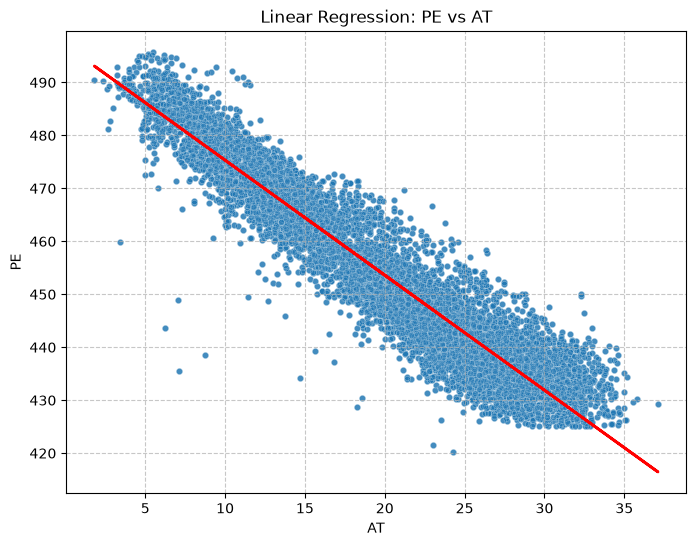

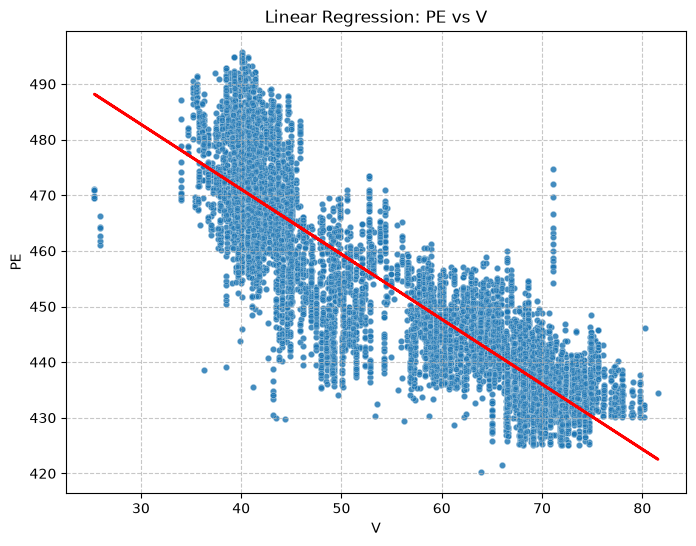

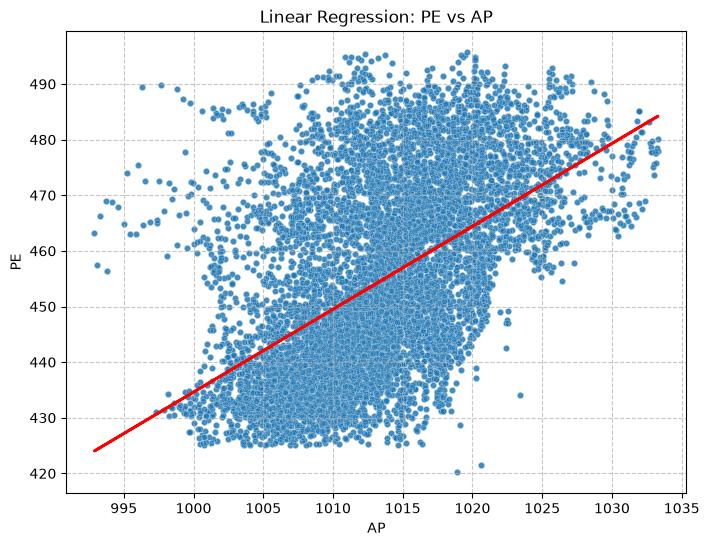

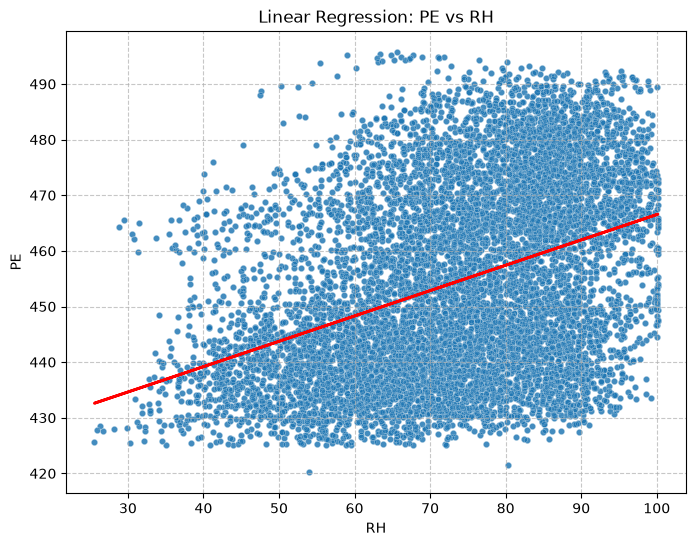

In [ ]:
import statsmodels.formula.api as smf
import seaborn as sns
# Model 1: AT and PE
model_at_pe = smf.ols('PE ~ AT', data=combined_df).fit()
print("\n--- Model: PE ~ AT ---")
print(model_at_pe.summary())


# Model 2: V and PE
model_v_pe = smf.ols('PE ~ V', data=combined_df).fit()
print("\n--- Model: PE ~ V ---")
print(model_v_pe.summary())



# Model 3: AP and PE
model_ap_pe = smf.ols('PE ~ AP', data=combined_df).fit()
print("\n--- Model: PE ~ AP ---")
print(model_ap_pe.summary())


# Model 4: RH and PE
model_rh_pe = smf.ols('PE ~ RH', data=combined_df).fit()
print("\n--- Model: PE ~ RH ---")
print(model_rh_pe.summary())


# Function to plot regression results
def plot_regression(model, x_var, y_var, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=combined_df[x_var], y=combined_df[y_var], alpha=0.3, s=20)
    # Add the regression line
    plt.plot(combined_df[x_var], model.predict(combined_df[x_var]), color='red', linewidth=2)
    plt.title(title)
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Plot Model 1: PE ~ AT
plot_regression(model_at_pe, 'AT', 'PE', 'Linear Regression: PE vs AT')

# Plot Model 2: PE ~ V
plot_regression(model_v_pe, 'V', 'PE', 'Linear Regression: PE vs V')

# Plot Model 3: PE ~ AP
plot_regression(model_ap_pe, 'AP', 'PE', 'Linear Regression: PE vs AP')

# Plot Model 4: PE ~ RH
plot_regression(model_rh_pe, 'RH', 'PE', 'Linear Regression: PE vs RH')



Based on the information, all predictors produced a P-Value of zero with Prob(F-statistic) of zero as well. This implies that the observed difference in the sample is exceptionally unlikely to be the result of random sampling from the population.

By visual means, the model of PE and AT seem to have a statistically significant relationship out of all of them based on that its R-squared value is closest to 1, but mathematically there is no statistical significance. Our null being a linear relationship between the predictor and energy output. With a p-value less than 0.0001, we can reject the null.

As for the removal of data outliers, while outliers can influence the mean, range, standard deviation and give us skewed results I would not want to remove them because there is no evidence of an abnormality of environment of when the data was recorded. (ex: heavy thunderstorm, bad weather, etc..). The combined cycle powerplant operates with a steam turbine and gas turbine so all the variables work with one another so it would not be reasonable to reomve the outlier of one of the variables but instead remove data from all variables in order to keep the populaiton size equal with one another.



**D. Multiple Regression**

In [ ]:
import statsmodels.formula.api as smf

# Fit a multiple regression model using all predictors
model_all_predictors = smf.ols('PE ~ AT + V + AP + RH', data=combined_df).fit()

# Print the summary of the multiple regression model
print("\n--- Multiple Regression Model: PE ~ AT + V + AP + RH ---")
print(model_all_predictors.summary())

print("""Since all intercepts have a P-value of less than 0.05,
we can reject the null hypothesis for all""")


--- Multiple Regression Model: PE ~ AT + V + AP + RH ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 1.558e+05
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:24:48   Log-Likelihood:            -1.4044e+05
No. Observations:               47840   AIC:                         2.809e+05
Df Residuals:                   47835   BIC:                         2.809e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

**E. Comparing Results**

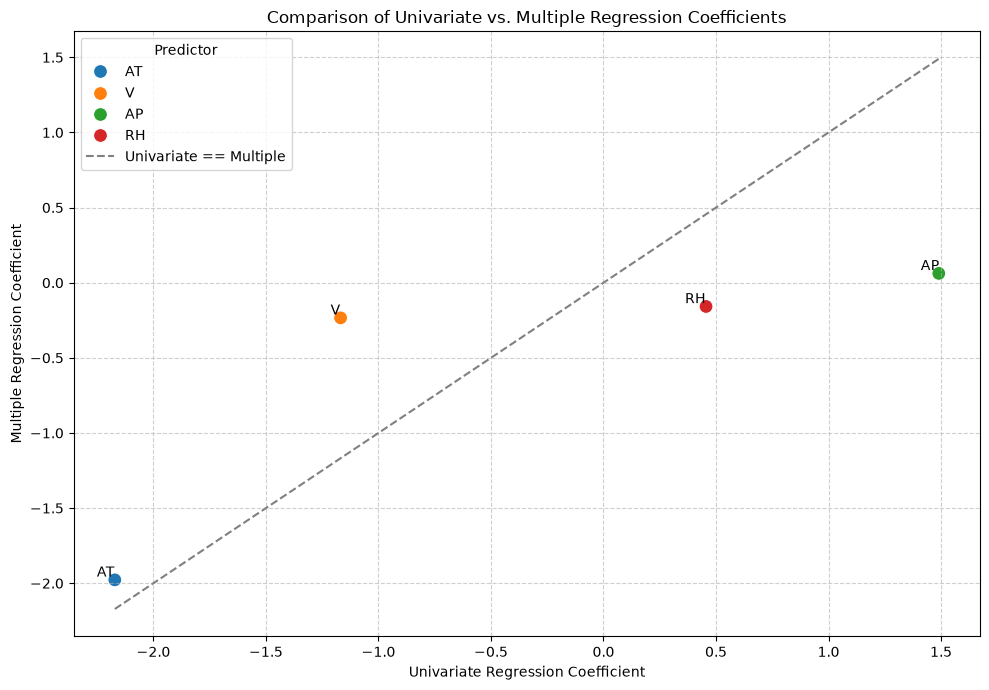

Based on R-squared, both predictors of AT and AV were the closest to 1


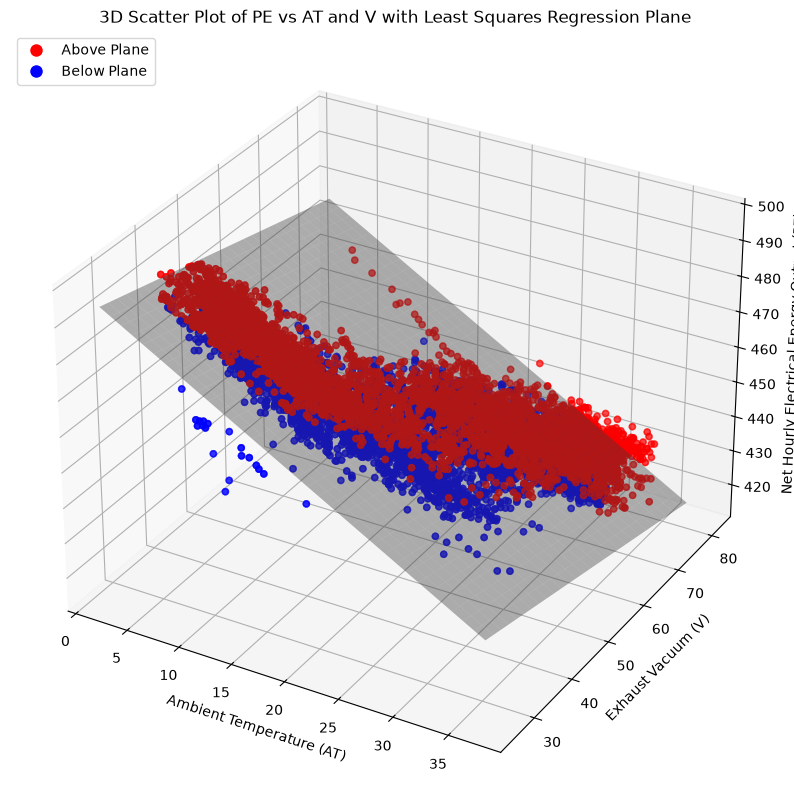

In [ ]:
# Extract coefficients from univariate models
univariate_coefficients = {
    'AT': model_at_pe.params['AT'],
    'V': model_v_pe.params['V'],
    'AP': model_ap_pe.params['AP'],
    'RH': model_rh_pe.params['RH']
}

# Extract coefficients from the multiple regression model
multiple_coefficients = {
    'AT': model_all_predictors.params['AT'],
    'V': model_all_predictors.params['V'],
    'AP': model_all_predictors.params['AP'],
    'RH': model_all_predictors.params['RH']
}

# Create a DataFrame for plotting
coefficients_df = pd.DataFrame({
    'Predictor': univariate_coefficients.keys(),
    'Univariate Coefficient': univariate_coefficients.values(),
    'Multiple Coefficient': multiple_coefficients.values()
})

# Create the scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Univariate Coefficient',
    y='Multiple Coefficient',
    hue='Predictor',
    data=coefficients_df,
    s=100
)

# Add labels for each point
for i, row in coefficients_df.iterrows():
    plt.text(row['Univariate Coefficient'], row['Multiple Coefficient'], row['Predictor'],
             ha='right', va='bottom', fontsize=10)

# Add a diagonal line for reference (where univariate == multiple)
min_val = min(coefficients_df['Univariate Coefficient'].min(), coefficients_df['Multiple Coefficient'].min())
max_val = max(coefficients_df['Univariate Coefficient'].max(), coefficients_df['Multiple Coefficient'].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='Univariate == Multiple')

plt.title('Comparison of Univariate vs. Multiple Regression Coefficients')
plt.xlabel('Univariate Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Predictor')
plt.tight_layout()
plt.show()

print("Based on R-squared, both predictors of AT and AV were the closest to 1")


# Fit a linear regression model with PE ~ AT + V
model_at_v_pe = smf.ols('PE ~ AT + V', data=combined_df).fit()

# Predict PE values using the model
combined_df['PE_pred'] = model_at_v_pe.predict(combined_df[['AT', 'V']])

# Calculate residuals (actual - predicted)
combined_df['residuals'] = combined_df['PE'] - combined_df['PE_pred']

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors based on residuals
colors = ['red' if r > 0 else 'blue' for r in combined_df['residuals']]

# Scatter plot of the data points, colored by whether they are above or below the plane
scatter = ax.scatter(
    combined_df['AT'],
    combined_df['V'],
    combined_df['PE'],
    c=colors,
    marker='o',
    alpha=0.6
)

# Create a meshgrid for the regression plane
x_surf = np.arange(combined_df['AT'].min(), combined_df['AT'].max(), 1)
y_surf = np.arange(combined_df['V'].min(), combined_df['V'].max(), 1)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Calculate the z-values for the regression plane
z_surf = model_at_v_pe.params['Intercept'] + model_at_v_pe.params['AT'] * x_surf + model_at_v_pe.params['V'] * y_surf

# Plot the regression plane
ax.plot_surface(x_surf, y_surf, z_surf, color='gray', alpha=0.4, label='Regression Plane')

# Set labels and title
ax.set_xlabel('Ambient Temperature (AT)')
ax.set_ylabel('Exhaust Vacuum (V)')
ax.set_zlabel('Net Hourly Electrical Energy Output (PE)')
ax.set_title('3D Scatter Plot of PE vs AT and V with Least Squares Regression Plane')

# Create a dummy legend for the colors
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Above Plane', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Below Plane', markerfacecolor='blue', markersize=10)
]
ax.legend(handles=legend_elements, loc='upper left')

plt.show()

**F. Evidence of nonlinear association**

In [14]:
import statsmodels.formula.api as smf

# Fit a multiple linear regression model with AT up to the 4th dimension to predict PE
model_at_poly_4 = smf.ols('PE ~ AT + I(AT**2) + I(AT**3) + I(AT**4)', data=combined_df).fit()

# Print the summary of the model
print("\n--- Multiple Linear Regression Model: PE ~ AT (up to 4th dimension) ---")
print(model_at_poly_4.summary())
print('***************************')
print('There is evidence of non linear association')
print('AT alone provides a p value greater than 0.05 meaning AT alone may not be statistically significant when higher order polynomials are involved')


--- Multiple Linear Regression Model: PE ~ AT (up to 4th dimension) ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 1.238e+05
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:53:26   Log-Likelihood:            -1.4550e+05
No. Observations:               47840   AIC:                         2.910e+05
Df Residuals:                   47835   BIC:                         2.911e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [9]:
import statsmodels.formula.api as smf

# Fit a multiple linear regression model with V up to the 4th dimension to predict PE
model_v_poly_4 = smf.ols('PE ~ V + I(V**2) + I(V**3) + I(V**4)', data=combined_df).fit()

# Print the summary of the model
print("\n--- Multiple Linear Regression Model: PE ~ V (up to 4th dimension) ---")
print(model_v_poly_4.summary())


--- Multiple Linear Regression Model: PE ~ V (up to 4th dimension) ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                 4.233e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:35:18   Log-Likelihood:            -1.6742e+05
No. Observations:               47840   AIC:                         3.349e+05
Df Residuals:                   47835   BIC:                         3.349e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [10]:
import statsmodels.formula.api as smf

# Fit a multiple linear regression model with AP up to the 4th dimension to predict PE
model_ap_poly_4 = smf.ols('PE ~ AP + I(AP**2) + I(AP**3) + I(AP**4)', data=combined_df).fit()

# Print the summary of the model
print("\n--- Multiple Linear Regression Model: PE ~ AP (up to 4th dimension) ---")
print(model_ap_poly_4.summary())


--- Multiple Linear Regression Model: PE ~ AP (up to 4th dimension) ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     9056.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:35:18   Log-Likelihood:            -1.9593e+05
No. Observations:               47840   AIC:                         3.919e+05
Df Residuals:                   47837   BIC:                         3.919e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

/tmp/ipykernel_2295/3962132710.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_ap_poly_4 = smf.ols('PE ~ AP + I(AP**2) + I(AP**3) + I(AP**4)', data=combined_df).fit()


In [11]:
import statsmodels.formula.api as smf

# Fit a multiple linear regression model with RH up to the 4th dimension to predict PE
model_rh_poly_4 = smf.ols('PE ~ RH + I(RH**2) + I(RH**3) + I(RH**4)', data=combined_df).fit()

# Print the summary of the model
print("\n--- Multiple Linear Regression Model: PE ~ RH (up to 4th dimension) ---")
print(model_rh_poly_4.summary())


--- Multiple Linear Regression Model: PE ~ RH (up to 4th dimension) ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     2173.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:35:19   Log-Likelihood:            -1.9962e+05
No. Observations:               47840   AIC:                         3.992e+05
Df Residuals:                   47835   BIC:                         3.993e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

**G. Association of interactions of predictors**

In [15]:
import statsmodels.formula.api as smf

# Fit a full linear regression model with all pairwise interaction terms
# The formula includes main effects + all two-way interaction terms
model_interactions = smf.ols(
    'PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH',
    data=combined_df
).fit()

# Print the summary of the model with interaction terms
print("\n--- Full Linear Regression Model with Pairwise Interaction Terms ---")
print(model_interactions.summary())


--- Full Linear Regression Model with Pairwise Interaction Terms ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 7.031e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:59:16   Log-Likelihood:            -1.3774e+05
No. Observations:               47840   AIC:                         2.755e+05
Df Residuals:                   47829   BIC:                         2.756e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

Almost all the models are statistically significant except for AT at AP with a p-value higher than 0.05. Temperature and pressure is not significantly different from the rest of the predictors


**ISLR 2.4.1**

a. Flexible would be worse, a simple methods like linear regression can easily give us a small number of predictions

b. Flexible would be better because we have a small number of observations which is difficult when needing a large number of predictors

c. Flexible would be better since flexible methods are for non-linear relationships

d. Flexible would be better because we want a lower variance. A high variance implies low accuracy.

**ISLR 2.4.7**

In [18]:
x1 = np.array([0, 2, 0, 0, -1, 1])
x2 = np.array([3, 0, 1, 1, 0, 1])
x3 = np.array([0, 0, 3, 2, 1, 1])
y = np.array([0, 0, 0, 1, 1, 0])

def euclidean_distance(obs, test_points) -> int:
    return np.sqrt(np.sum(np.abs(test_points[0] - x1[obs])**2 + np.abs(test_points[1] - x2[obs])**2 + np.abs(test_points[2] - x3[obs])**2))
test_points = [0, 0, 0]
print("(a) Euclidean distance between each observation and the test point, X1=X2=X3=0")
for i in range(6):
    print(i+1, "Green\t" if y[i] else "Red\t", euclidean_distance(i, test_points))

(a) Euclidean distance between each observation and the test point, X1=X2=X3=0
1 Red	 3.0
2 Red	 2.0
3 Red	 3.1622776601683795
4 Green	 2.23606797749979
5 Green	 1.4142135623730951
6 Red	 1.7320508075688772
